In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.special import factorial
import matplotlib.cm as cm
from matplotlib.colors import Normalize
import math
from IPython.display import Latex
from scipy.integrate import nquad

c=2.998*10**8 #in m/s
v0 = 220*1000/c
v_esc = 500*1000/c 
v_E = 240*1000/c 
w_minus = 60*10**-3
w_plus = 20*10**-3
ratio=v_esc/v0
N0 = v0**3*np.pi*(np.sqrt(np.pi)*scipy.special.erf(ratio)-2*ratio*np.exp(-ratio**2))
dm_density = 0.4e9
a0 = 2.68e-4 #eV^-1
target_density = 1.31e24 #GeV/cm^3
Z=14 #silicon
#dm_density = 0.4e9 #eV/cm^3, plus minus 0.1
Si_nucleus_mass = 931368088 #eV
w0=60e-3 #eV
proton_mass= 938.272e6 #eV
q0 = 56e3 #eV
ThomasFermi = 0.37 *a0
a_Si = 2*np.pi/(2.28*1000) 

def reducedMass(m1, m2):
    return m1*m2/(m1+m2)

def inverseMeanFunction_sol1(v_min, m_chi, const):
    summ = np.sqrt(np.pi)*v0*(scipy.special.erf((v_min+v_E)/v0)-scipy.special.erf((v_min-v_E)/v0))
    summ -= 4*np.exp(-v_esc**2/v0**2)*v_E
    return summ*const

def inverseMeanFunction_sol2(v_min, m_chi, const):
    summ = np.sqrt(np.pi)*v0*(scipy.special.erf(v_esc/v0)-scipy.special.erf((v_min-v_E)/v0))
    summ -= 2*np.exp(-v_esc**2/v0**2)*(v_esc-v_min+v_E)
    return summ*const

def inverseMeanFunction(v_min, m_chi, const = v0**2*np.pi/(2*v_E*N0)):
    """
    Returns the inverse mean value for any given v_min.  
    Parameters:
        v_min: input velocity
        m_chi: mass of dark matter
        const: scaling value for graphing.  As a default, it gives the true scale of the equation
    """
    if v_min>v_esc+v_E:
        return 0
    elif v_min>v_esc-v_E:
        return inverseMeanFunction_sol2(v_min,m_chi, const)
    else: 
        return inverseMeanFunction_sol1(v_min,m_chi, const)

In [2]:
def v_min(q,m_chi, w): #q in eV
    return w/q+q/(2*m_chi)

In [3]:
def ScatteringRate(R_q, parameters, q_bound):
    integral = scipy.integrate.nquad(R_q,[q_bound],
                                         args=parameters)[0]
    return integral

In [4]:
def debye_waller(q, m, w1,w2):
    return q**2/(8*m)*(1/w1+1/w2)

In [5]:
def diagonal_C_true(q, m, w1,w2, n, j, V=1):
    expDebyeWaller = np.exp(-2*debye_waller(q, m, w1,w2))
    c=expDebyeWaller/V * (q**2/(4*m))**n * 2*np.pi/(factorial(j)*factorial(n-j)*w1**j*w2**(n-j))
    return c

In [6]:
def offDiagonal_C_true(q, m, w1,w2, n, j, V=1, a=0.001):
    expDebyeWaller = np.exp(-2*debye_waller(q, m, w1,w2))
    c=expDebyeWaller/V * (q**2/(4*m))**n * 2*np.pi/(factorial(j)*factorial(n-j)* w1**j * w2**(n-j))
    if (n-j)%2==1:
        c = -c
    c = c*np.cos(q*a)
    return c

In [7]:
def StructureFactorIntegral_true(q, m, w1,w2, n, j, V=1, a=0.001, A=1):
    return 2*A**2*(diagonal_C_true(q, m, w1,w2, n, j, V)+offDiagonal_C_true(q, m, w1,w2, n, j, V, a))

In [8]:
def StructureFactorIntegral_allj(q, m, w1,w2, n, V=1, a=1, A=1):
    tot=0
    for j in range(n+1):
        tot+=StructureFactorIntegral_true(q, m, w1,w2, n, j, V, a, A)
    return tot

In [9]:
f=14
V=0.543*5.064225
m_Si = 28 * 9.31*1e8
def R_over_q_one_n(q, m_chi, n, sigma=1): #q in keV
    q=q*1000
    reducedmass = reducedMass(m_chi, proton_mass)
    consts = dm_density*sigma/(m_chi*target_density*2*np.pi*V*reducedmass**2)
    tot=0
    for j in range(n+1): #WRONG, j gets iterated here, and iterated again 3 lines down
        w=j*w_plus-j*w_minus+n*w_minus
        vmin = v_min(q, m_chi, w)
        tot+=StructureFactorIntegral_allj(q, m_Si, w_plus, w_minus, n, V, a_Si, f)*inverseMeanFunction(vmin, m_chi)
    return tot*consts*q*2.998e10 *3.15576e7 *1000

In [13]:
q_range = np.linspace(0,2.5,100)
q_range = 10**q_range
mX=40e6
R_q=[[R_over_q_one_n(q, mX, n) for q in q_range] for n in range(1, 11)]

(1e-14, 1e-06)

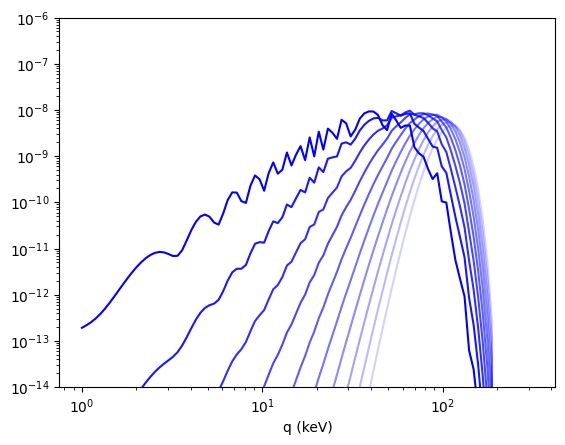

In [14]:
for i in range(10):
    plt.plot(q_range, R_q[i], alpha=(11-i)/11, color="blue", label=i+1)
#plt.legend()
plt.yscale("log")
plt.xscale("log")
plt.xlabel("q (keV)")
plt.ylim([1e-14, 1e-6])

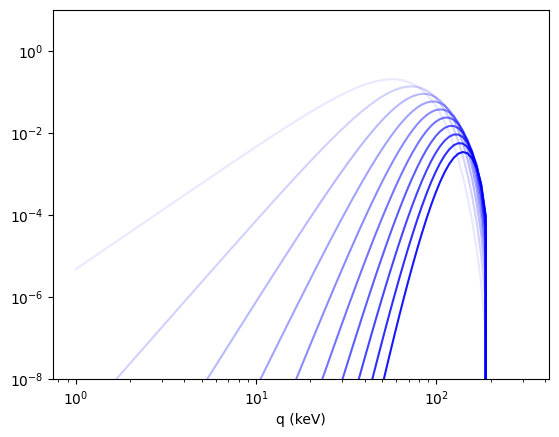

In [11]:
for i in range(10):
    plt.plot(q_range, deriv[i], color="blue", alpha=(i+1)/11)
plt.yscale("log")
plt.xscale("log")
plt.xlabel("q (keV)")
#plt.vlines(40e6*v0/1000, 10**-8, 1, color="grey", alpha=0.5)
plt.ylim([1e-8,10])
plt.show()